## 📌 Project Objective

Build an ANN classification model to detect whether customer would leave the bank affected by multiple features and this project would include,
- Data overview and analysis using EDA
- EDA charts and key insights
- ANN classification model
- Model evaluation
- Overview of the project through key business and learning insights

### Import required libraries

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

### Load the dataset

In [2]:
df = pd.read_csv("bank_customer_churn.csv")

### Dataset overview and EDA

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

#### Remove unnecessary columns from the dataset

In [17]:
df = df.drop(['RowNumber','CustomerId','Surname'], axis = 1)

#### Target distribution

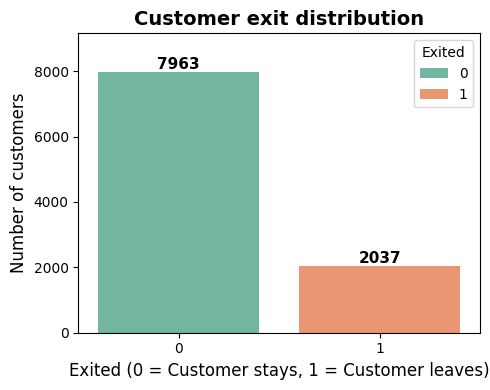

In [47]:
plt.figure(figsize=(5,4))

ax = sns.countplot(x='Exited', data=df, hue='Exited', palette='Set2', dodge=False)

# ---- TOP LABELS ----
for p in ax.patches:
    count = int(p.get_height())
    
    if count > 0:   # prevents showing 0 at bottom
        ax.annotate(f'{count}',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom',
                    fontsize=11, fontweight='bold')

# Increase Y-axis limit so top label is visible
plt.ylim(0, df['Exited'].value_counts().max() * 1.15)

plt.title('Customer exit distribution', fontsize=14, fontweight='bold')
plt.xlabel('Exited (0 = Customer stays, 1 = Customer leaves)', fontsize=12)
plt.ylabel('Number of customers', fontsize=12)

plt.tight_layout()
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\10_ANN_bank_customer_churn\images\customer_exit_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Correlation heatmap

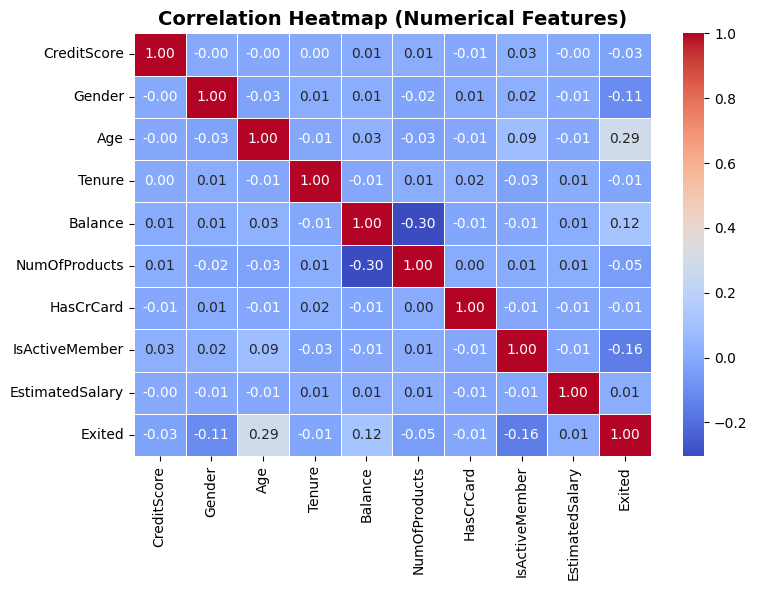

In [48]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap (Numerical Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\10_ANN_bank_customer_churn\images\correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Data preprocessing

#### Encode categorical columns

#### Gender -> label encoding

In [22]:
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})

#### Geography → One-Hot Encoding

In [23]:
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

#### Split features and target

In [24]:
X = df.drop('Exited', axis=1)
y = df['Exited']

#### Train-test split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Feature scaling

In [26]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Handle class imbalance with class_weight

In [27]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

### ANN Model

In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# -------- Build ANN --------
model = Sequential()

# Input Layer
model.add(Input(shape=(X_train.shape[1],)))

# Hidden Layer 1
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

# Hidden Layer 2
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# Hidden Layer 3
model.add(Dense(32, activation='relu'))

# Output
model.add(Dense(1, activation='sigmoid'))

# -------- Compile --------
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

# -------- Early Stopping --------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

### Train the model

In [38]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6577 - auc: 0.6925 - loss: 0.6386 - precision_2: 0.3256 - recall_2: 0.6135 - val_accuracy: 0.7169 - val_auc: 0.7890 - val_loss: 0.5581 - val_precision_2: 0.3869 - val_recall_2: 0.6957
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6936 - auc: 0.7623 - loss: 0.5836 - precision_2: 0.3737 - recall_2: 0.7148 - val_accuracy: 0.7319 - val_auc: 0.8033 - val_loss: 0.5432 - val_precision_2: 0.4076 - val_recall_2: 0.7329
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7119 - auc: 0.7886 - loss: 0.5581 - precision_2: 0.3934 - recall_2: 0.7284 - val_accuracy: 0.7606 - val_auc: 0.8160 - val_loss: 0.5065 - val_precision_2: 0.4412 - val_recall_2: 0.7112
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7291 - auc: 0.8017 - loss: 0.5444 - precision_2: 0.4137 - recall_2: 0.7474 - val_accuracy: 0.7619 - val_auc: 0.8266 - val_loss: 0.5055 - val_precision_2: 0.4444 - val_recall_2: 0.

### Model evaluation

In [43]:
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.45).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[1237  370]
 [  91  302]]
              precision    recall  f1-score   support

           0       0.93      0.77      0.84      1607
           1       0.45      0.77      0.57       393

    accuracy                           0.77      2000
   macro avg       0.69      0.77      0.71      2000
weighted avg       0.84      0.77      0.79      2000



#### ROC Curve

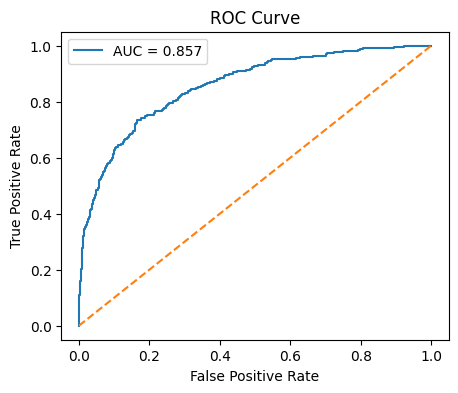

In [49]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\10_ANN_bank_customer_churn\images\ROC_AUC_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Precision-Recall Curve

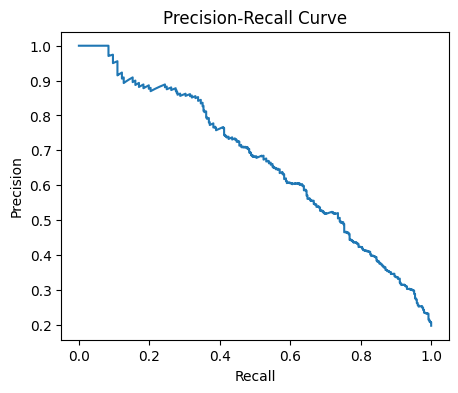

In [45]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(5,4))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

#### Confusion matrix heatmap

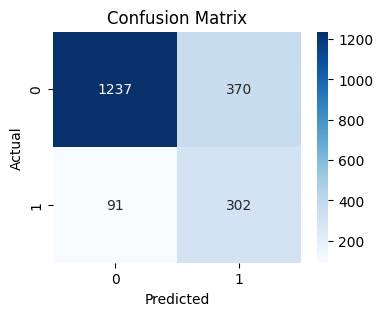

In [50]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\10_ANN_bank_customer_churn\images\confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 📌 Key insights and learning summary

### ANN Churn Prediction performance (Threshold = 0.45)
Accuracy: **0.77**
Churn Precision: **0.45**
Churn Recall: **0.77**
Churn F1-score: **0.57**

### 🧠 Key Analytical Insights

#### Customer behavior (Primary churn drivers)

- Age shows the strongest positive relation with churn → older customers leave more often
- Balance moderately increases churn probability → high balance customers are more likely to exit
- Inactive members (IsActiveMember = 0) have significantly higher churn tendency
- Customers with fewer products tend to churn more (low engagement)

#### Weak predictors

- Credit Score has almost no impact on churn in this dataset
- Has Credit Card does not meaningfully affect retention
- Estimated Salary shows negligible relationship with customer exit
- Tenure has very low correlation → long relationship does not guarantee loyalty

#### Customer engagement insight

- Product usage and account activity matter more than financial strength
- Churn is primarily a behavioral problem, not a credit-risk problem

#### Dataset pattern

- Highly imbalanced data (≈80% stay, 20% churn)
- Default 0.5 classification threshold was unsuitable
- Threshold tuning improved business usability by balancing recall and precision

### 🏁 Conclusion

Artificial Neural Network successfully models complex non-linear relationships in customer behavior and can identify potential churn customers with strong recall. The model is effective for early warning systems but produces some false positives, which is acceptable in retention campaigns.    

### Key business takeaway:
                                                                                                        
Customer churn is driven mainly by engagement level, activity, and product relationship, not by income or creditworthiness. Banks can reduce churn by targeting inactive and low-product customers with retention offers, cross-selling additional services, and proactive customer engagement rather than focusing only on high-income or high-credit customers.